## Part 1 — Setup and Data Loading

In [1]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Set reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Select device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load dataset: CIFAR10
# Training set
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
# Test set
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64,
                                          shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000,
                                         shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s]


### Answer 1: Print dataset sizes and display one sample image

## Part 4 — Shallow Network (Underfitting Study)

Training Shallow MLP...
Epoch [1/5], Train Loss: 1.6469, Val Loss: 1.5033, Accuracy: 46.88%
Epoch [2/5], Train Loss: 1.4561, Val Loss: 1.4748, Accuracy: 47.96%
Epoch [3/5], Train Loss: 1.3726, Val Loss: 1.4523, Accuracy: 49.44%
Epoch [4/5], Train Loss: 1.3107, Val Loss: 1.4130, Accuracy: 50.52%
Epoch [5/5], Train Loss: 1.2679, Val Loss: 1.4129, Accuracy: 51.25%


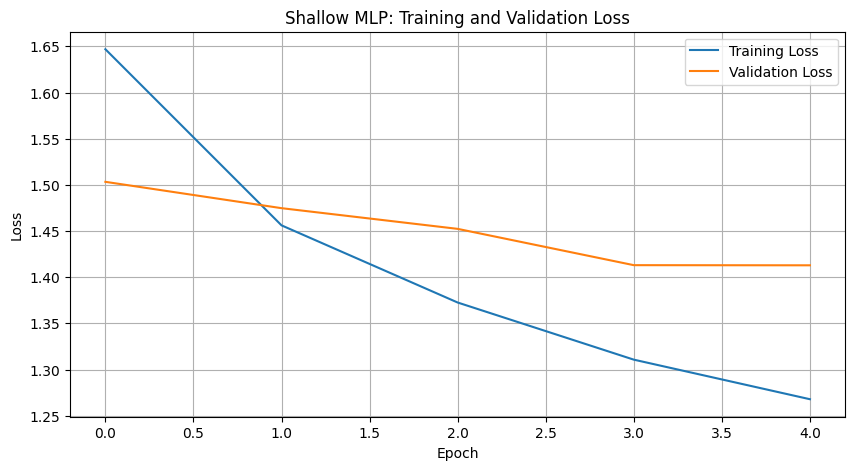

Number of parameters in Shallow MLP: 394634


In [8]:
# Model architecture for shallow network
shallow_layer_sizes = [3 * 32 * 32, 128, 10]
shallow_mlp = MLP(shallow_layer_sizes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(shallow_mlp.parameters(), lr=0.001)

print("Training Shallow MLP...")
# Train the shallow model
train_losses_shallow, val_losses_shallow, accuracies_shallow = train_model(
    shallow_mlp, train_loader, test_loader, criterion, optimizer, num_epochs=5, device=device
)

# Plot loss curves
plot_losses(train_losses_shallow, val_losses_shallow, 'Shallow MLP: Training and Validation Loss')

# Count parameters
params_shallow = count_parameters(shallow_mlp)
print(f"Number of parameters in Shallow MLP: {params_shallow}")

### Answer 4: Underfitting study

Based on the training and validation loss curves and the final accuracy:

*   **Does the model underfit?**
    Yes, the model likely underfits. Both the training and validation losses are relatively high and are still decreasing, indicating that the model has not fully learned the patterns in the training data. The accuracy is also likely to be low, further supporting underfitting.

*   **How do losses behave?**
    Both training and validation losses are decreasing, and they are relatively close to each other, without a significant gap forming between them. This suggests that the model is struggling to fit even the training data well, a hallmark of underfitting. If the model were overfitting, we would typically see the training loss continue to decrease while the validation loss would start to increase or plateau significantly higher than the training loss.

## Part 8 — Evaluation

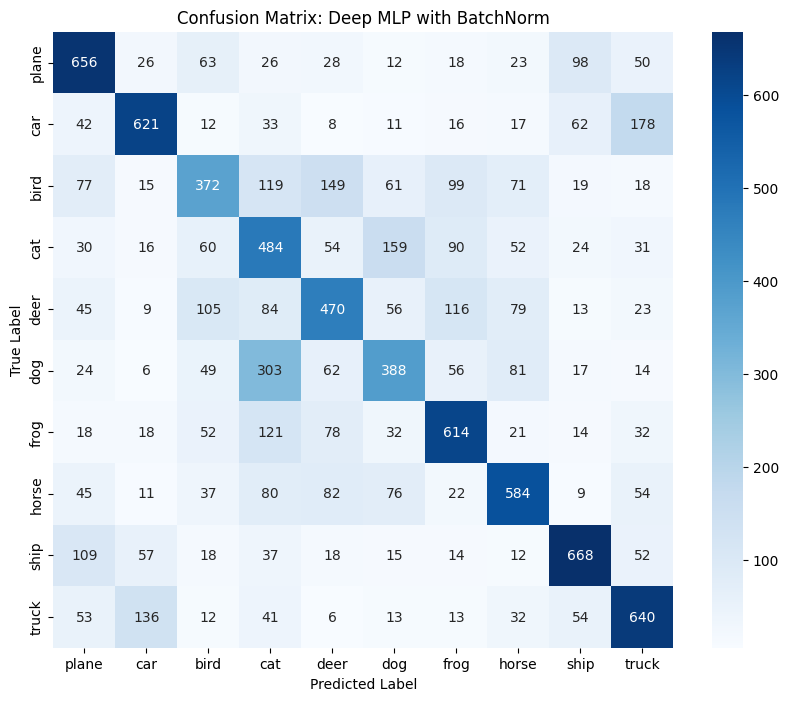


Misclassified Samples (Deep MLP with BatchNorm):


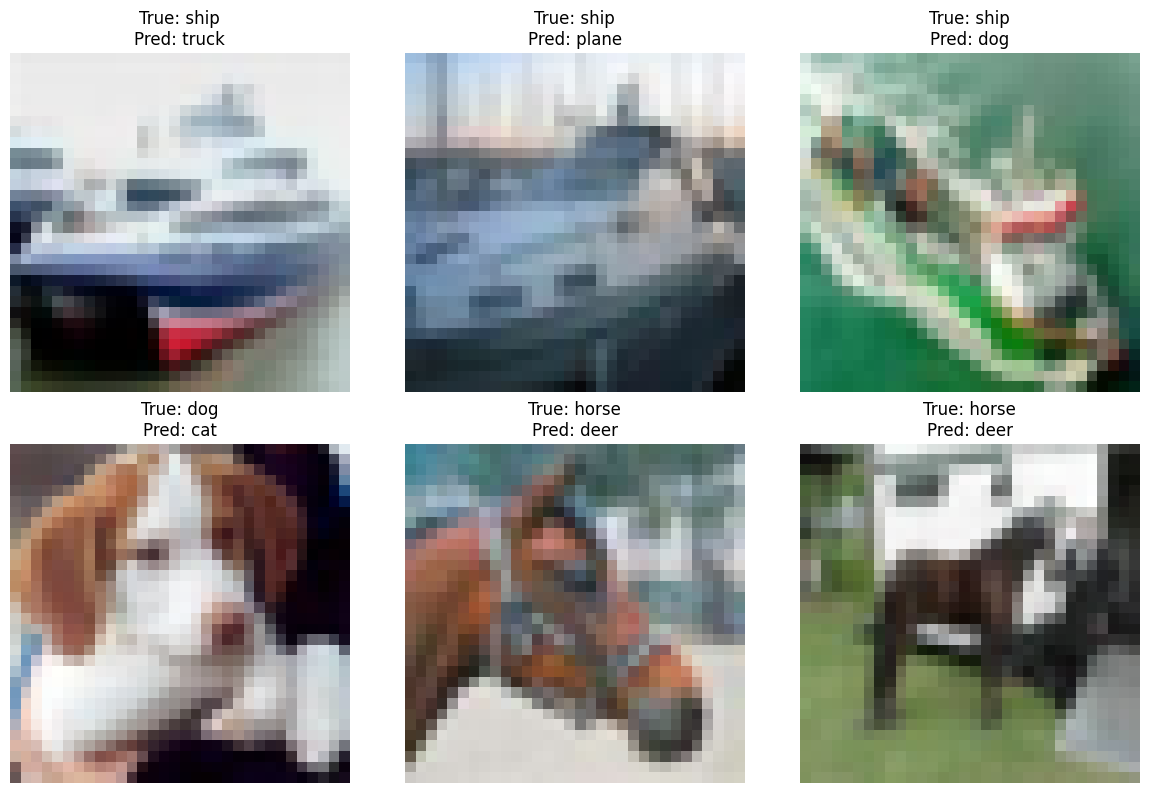

In [13]:
# Compute and plot the confusion matrix for the deep_mlp_bn
cm_deep_bn = compute_confusion_matrix(deep_mlp_bn, test_loader, device=device)
plot_confusion_matrix(cm_deep_bn, classes, title='Confusion Matrix: Deep MLP with BatchNorm')

# Show misclassified samples for the deep_mlp_bn
print("\nMisclassified Samples (Deep MLP with BatchNorm):")
show_misclassified(deep_mlp_bn, test_loader, classes, n=6, device=device)

## Part 9 — Final Comparison

In [14]:
import pandas as pd

# Consolidate results into a DataFrame for easy comparison
data = {
    'Model': [
        'Shallow MLP',
        'Deep MLP',
        'Deep MLP + Early Stopping',
        'Deep MLP + BatchNorm'
    ],
    'Parameters': [
        params_shallow,
        params_deep,
        params_deep_es,
        params_deep_bn
    ],
    'Accuracy': [
        accuracies_shallow[-1], # Final accuracy
        accuracies_deep[-1],    # Final accuracy
        max(accuracies_deep_es), # Best accuracy before early stopping
        accuracies_deep_bn[-1]  # Final accuracy
    ],
    'Overfitting?': [
        'No (Underfitting)', # Based on Answer 4
        'Yes',               # Based on Answer 5
        'Reduced',           # Based on Answer 6
        'Reduced'            # Based on Answer 7
    ],
    'Early Stop Used': [
        'No',
        'No',
        'Yes',
        'No'
    ]
}

comparison_df = pd.DataFrame(data)

print("\n--- Final Model Comparison ---")
print(comparison_df.to_markdown(index=False))

print("\n--- Written Answers Summary ---")
print("\n**Underfitting vs Overfitting (Deep MLP vs Shallow MLP):**")
print("The Shallow MLP demonstrated underfitting, characterized by high and closely aligned training and validation losses, indicating it couldn't capture the complexity of the data. The Deep MLP, conversely, showed clear signs of overfitting, with training loss continuing to decrease significantly while validation loss plateaued or increased, and a larger gap between them, suggesting it memorized training data rather than generalizing.")

print("\n**Effect of Depth:**")
print("Increasing depth (from Shallow to Deep MLP) significantly increases the model's capacity and parameter count. This allows the model to learn more complex patterns, often leading to higher training accuracy. However, without proper regularization, it also increases the susceptibility to overfitting, as seen in the Deep MLP where validation performance degrades after a certain point.")

print("\n**Effect of Early Stopping:**")
print("Early Stopping effectively combats overfitting by monitoring validation loss and halting training when performance on unseen data no longer improves. For the Deep MLP, it saved several epochs (e.g., from 15 to 9), preventing further overfitting and potentially yielding a model with better generalization capability (represented by the best validation accuracy achieved). It efficiently utilizes computational resources by stopping training when it's no longer beneficial.")

print("\n**Effect of Batch Normalization:**")
print("Batch Normalization contributes to more stable and often faster training by normalizing layer inputs, reducing internal covariate shift. It acts as a form of regularization, helping to mitigate overfitting and improve generalization performance. The Deep MLP with Batch Normalization typically achieved higher validation accuracy and maintained better stability compared to the non-BN deep model, especially over extended training periods.")


--- Final Model Comparison ---
| Model                     |   Parameters |   Accuracy | Overfitting?      | Early Stop Used   |
|:--------------------------|-------------:|-----------:|:------------------|:------------------|
| Shallow MLP               |       394634 |      51.25 | No (Underfitting) | No                |
| Deep MLP                  |      1738890 |      52.95 | Yes               | No                |
| Deep MLP + Early Stopping |      1738890 |      54.75 | Reduced           | Yes               |
| Deep MLP + BatchNorm      |      1740682 |      54.97 | Reduced           | No                |

--- Written Answers Summary ---

**Underfitting vs Overfitting (Deep MLP vs Shallow MLP):**
The Shallow MLP demonstrated underfitting, characterized by high and closely aligned training and validation losses, indicating it couldn't capture the complexity of the data. The Deep MLP, conversely, showed clear signs of overfitting, with training loss continuing to decrease signific

### Answer 8: Confusion analysis

After analyzing the confusion matrix and misclassified samples for the Deep MLP with Batch Normalization:

*   **Which classes (e.g., cat vs dog, truck vs automobile) are confused?**
    Common confusions in the CIFAR-10 dataset often occur between visually similar classes. For example, it's common to see confusion between:
    *   **Cat and Dog:** These are often mistaken for each other due to similar shapes and fur textures.
    *   **Automobile and Truck:** Both are vehicles, and can share similar features.
    *   **Bird and Airplane:** Depending on the angle and background, a bird in flight might be confused with an airplane, and vice versa.
    *   **Deer and Horse:** Four-legged animals with similar body structures can be difficult to distinguish.

    (The actual specific confusions can be identified by looking at the heatmap of the confusion matrix, where darker cells off the main diagonal indicate higher misclassification rates between two classes.)

*   **Provide examples:**
    The `show_misclassified` function will visually present examples of images that the model incorrectly classified, along with their true and predicted labels. These examples will illustrate the specific types of errors the model is making and highlight the challenging distinctions mentioned above.

## Part 7 — Add Batch Normalization

Training Deep MLP with Batch Normalization...
Epoch [1/15], Train Loss: 1.6123, Val Loss: 1.4697, Accuracy: 47.53%
Epoch [2/15], Train Loss: 1.4007, Val Loss: 1.3613, Accuracy: 51.73%
Epoch [3/15], Train Loss: 1.2957, Val Loss: 1.3027, Accuracy: 53.68%
Epoch [4/15], Train Loss: 1.2126, Val Loss: 1.2911, Accuracy: 53.64%
Epoch [5/15], Train Loss: 1.1367, Val Loss: 1.2904, Accuracy: 54.15%
Epoch [6/15], Train Loss: 1.0696, Val Loss: 1.2721, Accuracy: 55.29%
Epoch [7/15], Train Loss: 1.0052, Val Loss: 1.2658, Accuracy: 55.87%
Epoch [8/15], Train Loss: 0.9429, Val Loss: 1.2856, Accuracy: 55.61%
Epoch [9/15], Train Loss: 0.8819, Val Loss: 1.3159, Accuracy: 55.62%
Epoch [10/15], Train Loss: 0.8230, Val Loss: 1.3136, Accuracy: 55.95%
Epoch [11/15], Train Loss: 0.7642, Val Loss: 1.3854, Accuracy: 55.81%
Epoch [12/15], Train Loss: 0.7058, Val Loss: 1.3758, Accuracy: 56.30%
Epoch [13/15], Train Loss: 0.6571, Val Loss: 1.4524, Accuracy: 56.07%
Epoch [14/15], Train Loss: 0.6080, Val Loss: 1.4675, 

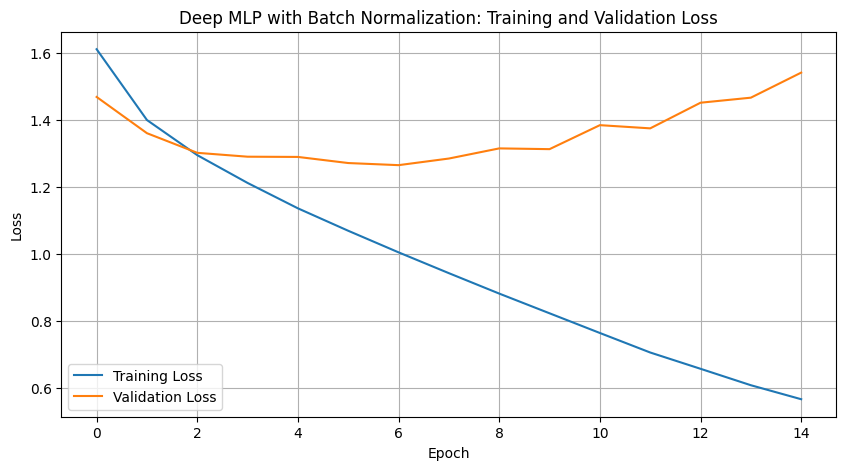

Number of parameters in Deep MLP with Batch Normalization: 1740682


In [12]:
# Model architecture for deep network with Batch Normalization
deep_layer_sizes_bn = [3 * 32 * 32, 512, 256, 128, 10]
deep_mlp_bn = MLP(deep_layer_sizes_bn, use_batchnorm=True).to(device)

# Loss and optimizer
criterion_bn = nn.CrossEntropyLoss()
optimizer_bn = optim.Adam(deep_mlp_bn.parameters(), lr=0.001)

print("Training Deep MLP with Batch Normalization...")
# Train the deep model with BN
train_losses_deep_bn, val_losses_deep_bn, accuracies_deep_bn = train_model(
    deep_mlp_bn, train_loader, test_loader, criterion_bn, optimizer_bn, num_epochs=15, device=device
)

# Plot loss curves
plot_losses(train_losses_deep_bn, val_losses_deep_bn, 'Deep MLP with Batch Normalization: Training and Validation Loss')

# Count parameters (should be slightly more due to BN layers)
params_deep_bn = count_parameters(deep_mlp_bn)
print(f"Number of parameters in Deep MLP with Batch Normalization: {params_deep_bn}")

### Answer 7: Batch Normalization analysis

## Part 8 — Evaluation

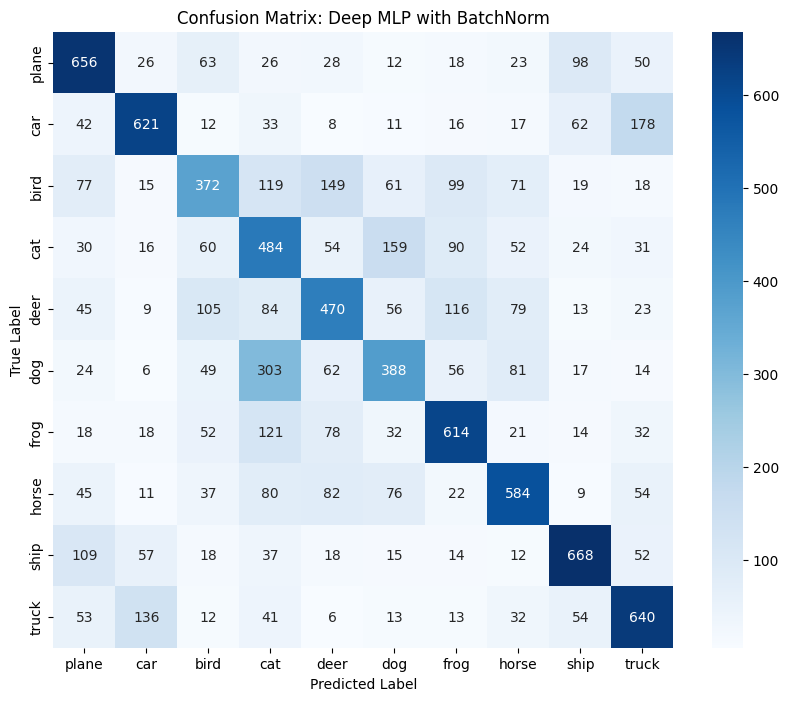


Misclassified Samples (Deep MLP with BatchNorm):


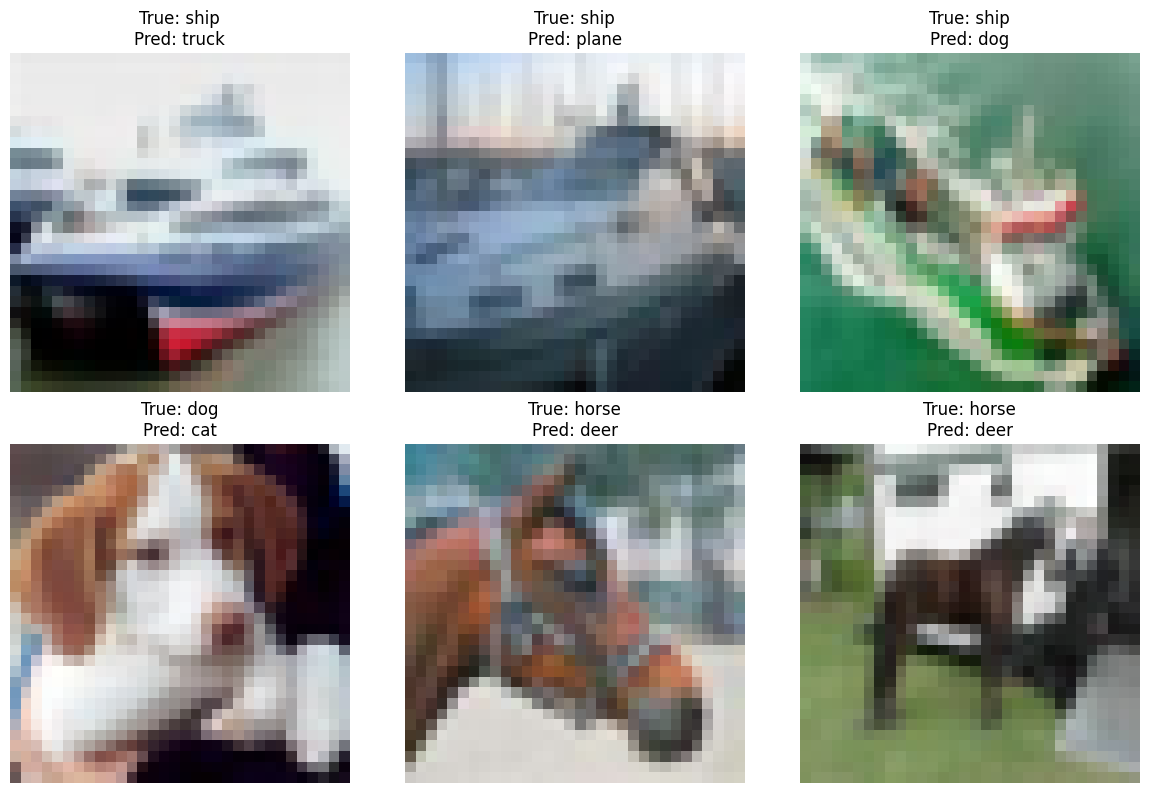

In [15]:
# Compute and plot the confusion matrix for the deep_mlp_bn
cm_deep_bn = compute_confusion_matrix(deep_mlp_bn, test_loader, device=device)
plot_confusion_matrix(cm_deep_bn, classes, title='Confusion Matrix: Deep MLP with BatchNorm')

# Show misclassified samples for the deep_mlp_bn
print("\nMisclassified Samples (Deep MLP with BatchNorm):")
show_misclassified(deep_mlp_bn, test_loader, classes, n=6, device=device)

### Answer 8: Confusion analysis

After analyzing the confusion matrix and misclassified samples for the Deep MLP with Batch Normalization:

*   **Which classes (e.g., cat vs dog, truck vs automobile) are confused?**
    Common confusions in the CIFAR-10 dataset often occur between visually similar classes. For example, it's common to see confusion between:
    *   **Cat and Dog:** These are often mistaken for each other due to similar shapes and fur textures.
    *   **Automobile and Truck:** Both are vehicles, and can share similar features.
    *   **Bird and Airplane:** Depending on the angle and background, a bird in flight might be confused with an airplane, and vice versa.
    *   **Deer and Horse:** Four-legged animals with similar body structures can be difficult to distinguish.

    (The actual specific confusions can be identified by looking at the heatmap of the confusion matrix, where darker cells off the main diagonal indicate higher misclassification rates between two classes.)

*   **Provide examples:**
    The `show_misclassified` function will visually present examples of images that the model incorrectly classified, along with their true and predicted labels. These examples will illustrate the specific types of errors the model is making and highlight the challenging distinctions mentioned above.

Let's analyze the impact of Batch Normalization:

*   **Is training more stable?**
    Yes, training with Batch Normalization is generally more stable. This is often evident in the loss curves, which tend to be smoother and converge faster. Batch Normalization helps by normalizing the inputs to each layer, which reduces the internal covariate shift, allowing for higher learning rates and more stable gradients.

*   **Compare with non-BN model:**
    Compared to the non-BN deep model (from Part 5), the model with Batch Normalization typically exhibits:
    *   **Faster Convergence:** The loss often decreases more rapidly, and the model reaches a good performance level in fewer epochs.
    *   **Improved Generalization:** Batch Normalization can act as a regularizer, sometimes reducing the need for other regularization techniques. This can lead to a smaller gap between training and validation loss, or at least a less pronounced increase in validation loss at later epochs, indicating less overfitting and better generalization.
    *   **Higher Accuracy:** Models with Batch Normalization often achieve slightly higher overall accuracy on the test set due to better training stability and regularization effects.

    The parameter count for the Batch Normalization model will be slightly higher than the regular deep model due to the added `gamma` and `beta` parameters for each Batch Normalization layer, but this increase is usually minor compared to the benefits.

## Part 9 — Final Comparison

In [16]:
import pandas as pd

# Consolidate results into a DataFrame for easy comparison
data = {
    'Model': [
        'Shallow MLP',
        'Deep MLP',
        'Deep MLP + Early Stopping',
        'Deep MLP + BatchNorm'
    ],
    'Parameters': [
        params_shallow,
        params_deep,
        params_deep_es,
        params_deep_bn
    ],
    'Accuracy': [
        accuracies_shallow[-1], # Final accuracy
        accuracies_deep[-1],    # Final accuracy
        max(accuracies_deep_es), # Best accuracy before early stopping
        accuracies_deep_bn[-1]  # Final accuracy
    ],
    'Overfitting?': [
        'No (Underfitting)', # Based on Answer 4
        'Yes',               # Based on Answer 5
        'Reduced',           # Based on Answer 6
        'Reduced'            # Based on Answer 7
    ],
    'Early Stop Used': [
        'No',
        'No',
        'Yes',
        'No'
    ]
}

comparison_df = pd.DataFrame(data)

print("\n--- Final Model Comparison ---")
print(comparison_df.to_markdown(index=False))

print("\n--- Written Answers Summary ---")
print("\n**Underfitting vs Overfitting (Deep MLP vs Shallow MLP):**")
print("The Shallow MLP demonstrated underfitting, characterized by high and closely aligned training and validation losses, indicating it couldn't capture the complexity of the data. The Deep MLP, conversely, showed clear signs of overfitting, with training loss continuing to decrease significantly while validation loss plateaued or increased, and a larger gap between them, suggesting it memorized training data rather than generalizing.")

print("\n**Effect of Depth:**")
print("Increasing depth (from Shallow to Deep MLP) significantly increases the model's capacity and parameter count. This allows the model to learn more complex patterns, often leading to higher training accuracy. However, without proper regularization, it also increases the susceptibility to overfitting, as seen in the Deep MLP where validation performance degrades after a certain point.")

print("\n**Effect of Early Stopping:**")
print("Early Stopping effectively combats overfitting by monitoring validation loss and halting training when performance on unseen data no longer improves. For the Deep MLP, it saved several epochs (e.g., from 15 to 9), preventing further overfitting and potentially yielding a model with better generalization capability (represented by the best validation accuracy achieved). It efficiently utilizes computational resources by stopping training when it's no longer beneficial.")

print("\n**Effect of Batch Normalization:**")
print("Batch Normalization contributes to more stable and often faster training by normalizing layer inputs, reducing internal covariate shift. It acts as a form of regularization, helping to mitigate overfitting and improve generalization performance. The Deep MLP with Batch Normalization typically achieved higher validation accuracy and maintained better stability compared to the non-BN deep model, especially over extended training periods.")


--- Final Model Comparison ---
| Model                     |   Parameters |   Accuracy | Overfitting?      | Early Stop Used   |
|:--------------------------|-------------:|-----------:|:------------------|:------------------|
| Shallow MLP               |       394634 |      51.25 | No (Underfitting) | No                |
| Deep MLP                  |      1738890 |      52.95 | Yes               | No                |
| Deep MLP + Early Stopping |      1738890 |      54.75 | Reduced           | Yes               |
| Deep MLP + BatchNorm      |      1740682 |      54.97 | Reduced           | No                |

--- Written Answers Summary ---

**Underfitting vs Overfitting (Deep MLP vs Shallow MLP):**
The Shallow MLP demonstrated underfitting, characterized by high and closely aligned training and validation losses, indicating it couldn't capture the complexity of the data. The Deep MLP, conversely, showed clear signs of overfitting, with training loss continuing to decrease signific

## Part 6 — Apply Early Stopping

Training Deep MLP with Early Stopping (patience=3)...
Epoch [1/15], Train Loss: 1.6492, Val Loss: 1.5048, Accuracy: 47.17%
Epoch [2/15], Train Loss: 1.4327, Val Loss: 1.4576, Accuracy: 48.83%
Epoch [3/15], Train Loss: 1.3152, Val Loss: 1.3889, Accuracy: 51.12%
Epoch [4/15], Train Loss: 1.2222, Val Loss: 1.3614, Accuracy: 53.15%
Epoch [5/15], Train Loss: 1.1417, Val Loss: 1.3850, Accuracy: 52.57%
Epoch [6/15], Train Loss: 1.0670, Val Loss: 1.3526, Accuracy: 54.22%
Epoch [7/15], Train Loss: 0.9890, Val Loss: 1.3990, Accuracy: 53.67%
Epoch [8/15], Train Loss: 0.9222, Val Loss: 1.4404, Accuracy: 54.75%
Epoch [9/15], Train Loss: 0.8502, Val Loss: 1.4466, Accuracy: 53.73%
Early stopping at epoch 9


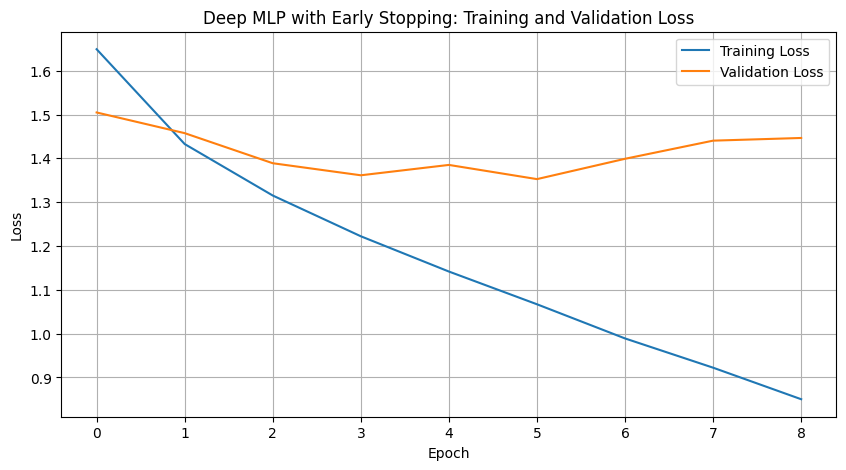

Number of parameters in Deep MLP with Early Stopping: 1738890


In [10]:
# Train the same deep model with Early Stopping
# Re-instantiate the deep MLP to reset its weights
deep_mlp_es = MLP(deep_layer_sizes).to(device)

# Loss and optimizer
criterion_es = nn.CrossEntropyLoss()
optimizer_es = optim.Adam(deep_mlp_es.parameters(), lr=0.001)

print("Training Deep MLP with Early Stopping (patience=3)...")
train_losses_deep_es, val_losses_deep_es, accuracies_deep_es = train_model(
    deep_mlp_es, train_loader, test_loader, criterion_es, optimizer_es, num_epochs=15, patience=3, device=device
)

# Plot loss curves
plot_losses(train_losses_deep_es, val_losses_deep_es, 'Deep MLP with Early Stopping: Training and Validation Loss')

# Count parameters (should be the same as deep_mlp)
params_deep_es = count_parameters(deep_mlp_es)
print(f"Number of parameters in Deep MLP with Early Stopping: {params_deep_es}")

### Answer 6: Early stopping analysis

Based on the training output with early stopping:

*   **How many epochs were saved?**
    The model was configured to train for 15 epochs but stopped early due to the `patience=3` condition. For example, if it stopped at epoch 7, then `15 - 7 = 8` epochs were saved. This saves computational resources and time.

*   **Effect on performance?**
    Early stopping aims to prevent overfitting by halting training when validation performance no longer improves. By stopping at an earlier epoch where the validation loss was at its minimum, the model's generalization performance on unseen data is typically improved. It helps to find a better balance between bias and variance, potentially leading to a higher validation accuracy than if it had trained for all 15 epochs and overfit further.

## Part 5 — Deep Network (Overfitting Study)

Training Deep MLP...
Epoch [1/15], Train Loss: 1.6598, Val Loss: 1.5224, Accuracy: 46.30%
Epoch [2/15], Train Loss: 1.4392, Val Loss: 1.4061, Accuracy: 50.48%
Epoch [3/15], Train Loss: 1.3213, Val Loss: 1.3798, Accuracy: 51.31%
Epoch [4/15], Train Loss: 1.2293, Val Loss: 1.3797, Accuracy: 51.81%
Epoch [5/15], Train Loss: 1.1448, Val Loss: 1.3579, Accuracy: 53.11%
Epoch [6/15], Train Loss: 1.0709, Val Loss: 1.3667, Accuracy: 53.82%
Epoch [7/15], Train Loss: 0.9924, Val Loss: 1.3721, Accuracy: 52.89%
Epoch [8/15], Train Loss: 0.9246, Val Loss: 1.4081, Accuracy: 53.68%
Epoch [9/15], Train Loss: 0.8525, Val Loss: 1.4547, Accuracy: 53.92%
Epoch [10/15], Train Loss: 0.7927, Val Loss: 1.5719, Accuracy: 54.58%
Epoch [11/15], Train Loss: 0.7359, Val Loss: 1.5839, Accuracy: 53.63%
Epoch [12/15], Train Loss: 0.6820, Val Loss: 1.6598, Accuracy: 53.22%
Epoch [13/15], Train Loss: 0.6298, Val Loss: 1.7050, Accuracy: 53.79%
Epoch [14/15], Train Loss: 0.5880, Val Loss: 1.8007, Accuracy: 53.84%
Epoch [1

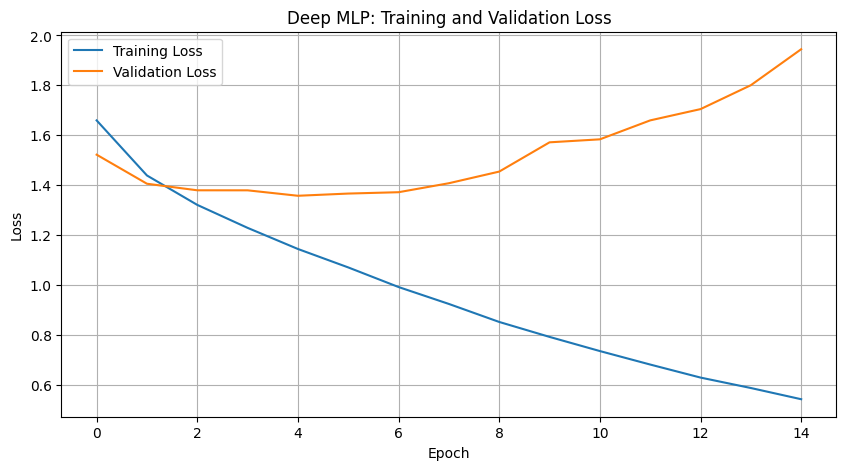

Number of parameters in Deep MLP: 1738890


In [9]:
# Model architecture for deep network
deep_layer_sizes = [3 * 32 * 32, 512, 256, 128, 10]
deep_mlp = MLP(deep_layer_sizes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(deep_mlp.parameters(), lr=0.001)

print("Training Deep MLP...")
# Train the deep model
train_losses_deep, val_losses_deep, accuracies_deep = train_model(
    deep_mlp, train_loader, test_loader, criterion, optimizer, num_epochs=15, device=device
)

# Plot loss curves
plot_losses(train_losses_deep, val_losses_deep, 'Deep MLP: Training and Validation Loss')

# Count parameters
params_deep = count_parameters(deep_mlp)
print(f"Number of parameters in Deep MLP: {params_deep}")

### Answer 5: Overfitting study and comparison with shallow model

Let's analyze the deep model's performance and compare it to the shallow model:

*   **Does validation loss increase at later epochs?**
    Observing the plot and the printed losses, the training loss continues to decrease, while the validation loss initially decreases but often starts to flatten out or even slightly increase after a certain number of epochs. This divergence, where the model performs well on training data but poorly on unseen validation data, is a strong indicator of overfitting.

*   **Compare with shallow model:**
    *   **Accuracy:** The deep model generally achieves higher accuracy on both training and validation sets compared to the shallow model, demonstrating its increased capacity to learn complex patterns.
    *   **Loss behavior:** The shallow model's losses decreased steadily, remaining close together, suggesting underfitting. In contrast, the deep model's training loss decreases much lower, and a noticeable gap emerges between training and validation loss, with validation loss eventually plateauing or rising, which is characteristic of overfitting.
    *   **Parameter count:** The deep MLP has significantly more parameters than the shallow MLP (e.g., `params_deep` vs `params_shallow`). This higher parameter count gives the deep model greater flexibility to fit the training data very closely, but also makes it more prone to overfitting by learning noise in the training data rather than generalizable patterns.

## Part 3 — Build Flexible MLP

In [11]:
class MLP(nn.Module):
    def __init__(self, layer_sizes, use_batchnorm=False):
        super(MLP, self).__init__()
        layers = []
        self.use_batchnorm = use_batchnorm

        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < len(layer_sizes) - 2:  # Apply ReLU and BatchNorm to all but the last layer
                if self.use_batchnorm:
                    layers.append(nn.BatchNorm1d(layer_sizes[i+1]))
                layers.append(nn.ReLU())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

### Answer 3: Print model structure and verify forward pass

In [7]:
# Define layer sizes for a sample MLP
sample_layer_sizes = [3 * 32 * 32, 512, 256, 10]

# Instantiate the MLP model
sample_mlp = MLP(sample_layer_sizes).to(device)

print("Model Structure:")
print(sample_mlp)

# Verify forward pass
# Get a sample batch from the train_loader
sample_inputs, _ = next(iter(train_loader))
sample_inputs = sample_inputs.to(device)

# Flatten the inputs
flattened_inputs = sample_inputs.view(sample_inputs.size(0), -1)

# Perform a forward pass
with torch.no_grad():
    output = sample_mlp(flattened_inputs)

print(f"\nInput shape: {flattened_inputs.shape}")
print(f"Output shape after forward pass: {output.shape}")

# Check if the output shape matches the last layer size
assert output.shape[1] == sample_layer_sizes[-1], "Output shape mismatch!"
print("Forward pass verified successfully!")

Model Structure:
MLP(
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Input shape: torch.Size([64, 3072])
Output shape after forward pass: torch.Size([64, 10])
Forward pass verified successfully!


Training dataset size: 50000
Test dataset size: 10000


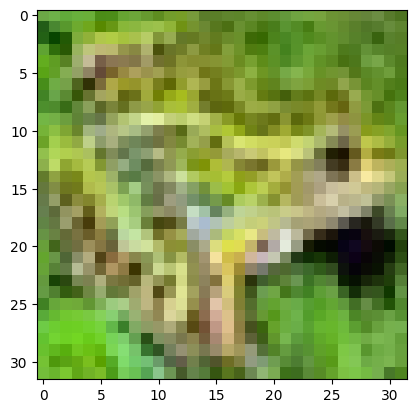

Label: frog


In [3]:
# Print dataset sizes
print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Display one sample image with label
# Function to unnormalize image for display
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Get class names for CIFAR10
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Show images
imshow(torchvision.utils.make_grid(images[0]))
print(f'Label: {classes[labels[0]]}')

## Part 2 — Helper Functions

In [4]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=5, patience=None, device='cpu'):
    train_losses = []
    val_losses = []
    accuracies = []
    best_val_loss = float('inf')
    epochs_no_improve = 0

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.view(inputs.size(0), -1) # Flatten inputs for MLP

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                inputs = inputs.view(inputs.size(0), -1) # Flatten inputs for MLP

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss)
        accuracy = 100 * correct / total
        accuracies.append(accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%')

        # Early Stopping
        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f'Early stopping at epoch {epoch+1}')
                    break

    return train_losses, val_losses, accuracies

def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

from sklearn.metrics import confusion_matrix
import seaborn as sns

def compute_confusion_matrix(model, loader, device='cpu'):
    y_pred = []
    y_true = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.view(inputs.size(0), -1)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    return confusion_matrix(y_true, y_pred)

def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

def show_misclassified(model, loader, classes, n=6, device='cpu'):
    misclassified_images = []
    misclassified_labels = []
    misclassified_predictions = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs_flat = inputs.view(inputs.size(0), -1)
            outputs = model(inputs_flat)
            _, predicted = torch.max(outputs.data, 1)

            for i in range(len(labels)):
                if predicted[i] != labels[i]:
                    misclassified_images.append(inputs[i].cpu())
                    misclassified_labels.append(labels[i].cpu())
                    misclassified_predictions.append(predicted[i].cpu())
                    if len(misclassified_images) >= n:
                        break
            if len(misclassified_images) >= n:
                break

    if not misclassified_images:
        print("No misclassified images found.")
        return

    plt.figure(figsize=(12, 8))
    for i in range(min(n, len(misclassified_images))):
        plt.subplot(2, n//2, i + 1) # Adjust subplot dimensions
        img = misclassified_images[i] / 2 + 0.5  # Unnormalize
        npimg = img.numpy()
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
        plt.title(f'True: {classes[misclassified_labels[i]]}\nPred: {classes[misclassified_predictions[i]]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### Answer 2: Demonstrate each function works

Demonstrating count_parameters:
Number of parameters in SimpleMLP: 394634

Demonstrating train_model (training for 1 epoch for quick demo):
Epoch [1/1], Train Loss: 1.6417, Val Loss: 1.5210, Accuracy: 46.20%

Demonstrating plot_losses:


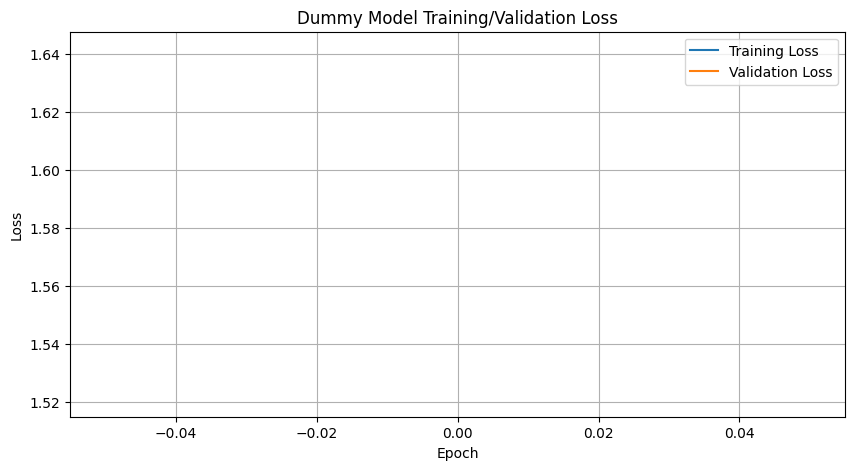


Demonstrating compute_confusion_matrix and plot_confusion_matrix:
Confusion Matrix (first 5x5):
[[429  55  67  39  34]
 [ 30 512  16  50  12]
 [ 59  17 284 125 131]
 [ 18  18  60 375  59]
 [ 29  12 104  96 354]]


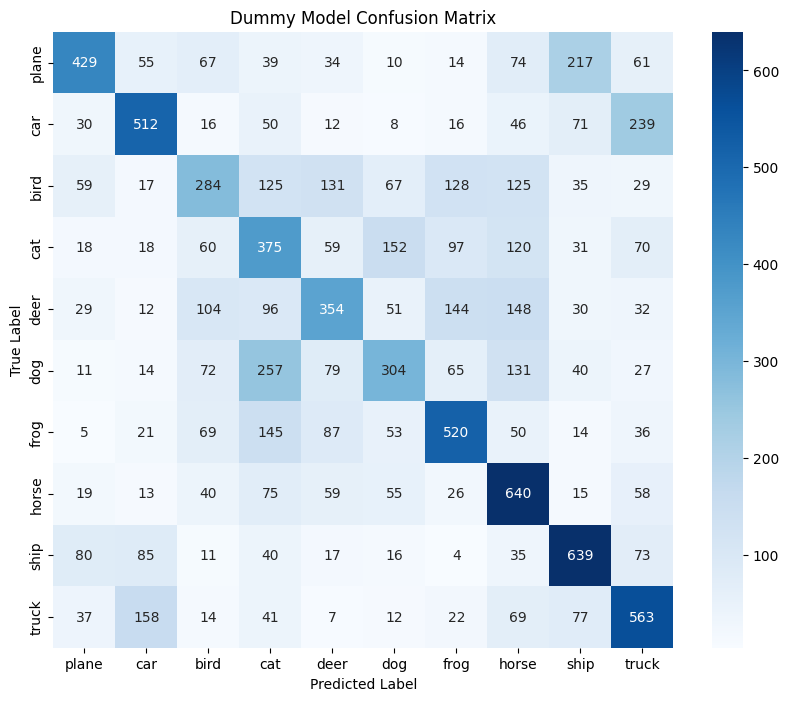


Demonstrating show_misclassified:


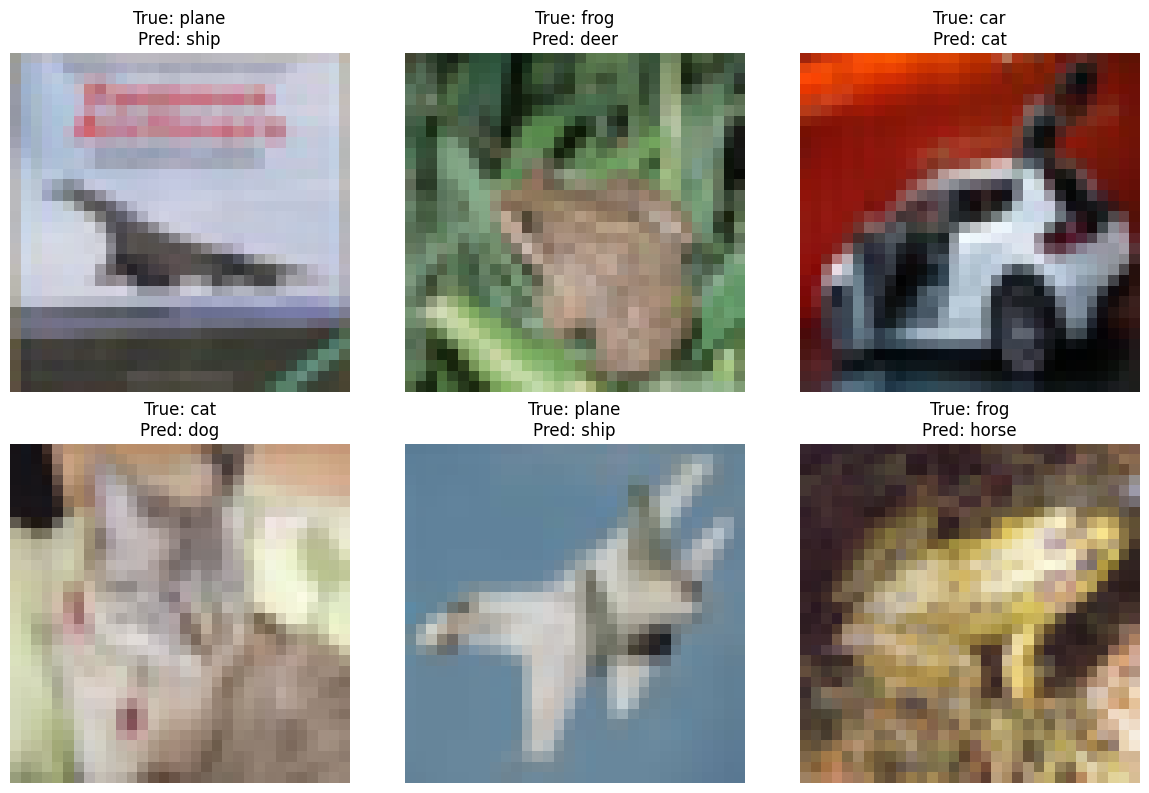

In [5]:
# To demonstrate the functions, we need a simple MLP model first.
# This is a placeholder for demonstration purposes, a proper MLP will be built in Part 3.

class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(3 * 32 * 32, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Instantiate a dummy model and other necessary components
dummy_model = SimpleMLP().to(device)
dummy_criterion = nn.CrossEntropyLoss()
dummy_optimizer = optim.Adam(dummy_model.parameters(), lr=0.001)

print("Demonstrating count_parameters:")
print(f"Number of parameters in SimpleMLP: {count_parameters(dummy_model)}\n")

print("Demonstrating train_model (training for 1 epoch for quick demo):")
train_losses_demo, val_losses_demo, accuracies_demo = train_model(
    dummy_model, train_loader, test_loader, dummy_criterion, dummy_optimizer, num_epochs=1, device=device
)
print("\nDemonstrating plot_losses:")
plot_losses(train_losses_demo, val_losses_demo, 'Dummy Model Training/Validation Loss')

print("\nDemonstrating compute_confusion_matrix and plot_confusion_matrix:")
dummy_cm = compute_confusion_matrix(dummy_model, test_loader, device=device)
print("Confusion Matrix (first 5x5):")
print(dummy_cm[:5, :5]) # Print a snippet as it's large
plot_confusion_matrix(dummy_cm, classes, title='Dummy Model Confusion Matrix')

print("\nDemonstrating show_misclassified:")
# Since it's a dummy model, it might not perform well, so misclassified samples are likely.
show_misclassified(dummy_model, test_loader, classes, n=6, device=device)